In [1]:
%cd ..

/home/bhchen/LearnKalmanGain


In [7]:
import torch
import matplotlib.pyplot as plt
import math, os

--- Starting Data Averaging Process ---
Successfully created: data/lorenz63/pf_results_sigma_y_1.0_batch_64_len_500_pfN_1000_avg.pt
Successfully created: data/lorenz63/pf_results_sigma_y_1.0_batch_64_len_500_pfN_2000_avg.pt
Successfully created: data/lorenz63/pf_results_sigma_y_1.0_batch_64_len_500_pfN_5000_avg.pt
Successfully created: data/lorenz63/pf_results_sigma_y_1.0_batch_64_len_500_pfN_10000_avg.pt
Successfully created: data/lorenz63/pf_results_sigma_y_1.0_batch_64_len_500_pfN_20000_avg.pt
Successfully created: data/lorenz63/pf_results_sigma_y_1.0_batch_64_len_500_pfN_50000_avg.pt
Successfully created: data/lorenz63/pf_results_sigma_y_1.0_batch_64_len_500_pfN_100000_avg.pt
Successfully created: data/lorenz63/pf_results_sigma_y_1.0_batch_64_len_500_pfN_200000_avg.pt
Successfully created: data/lorenz63/pf_results_sigma_y_1.0_batch_64_len_500_pfN_500000_avg.pt
Successfully created: data/lorenz63/pf_results_sigma_y_1.0_batch_64_len_500_pfN_1000000_avg.pt

--- Data Averaging Complete

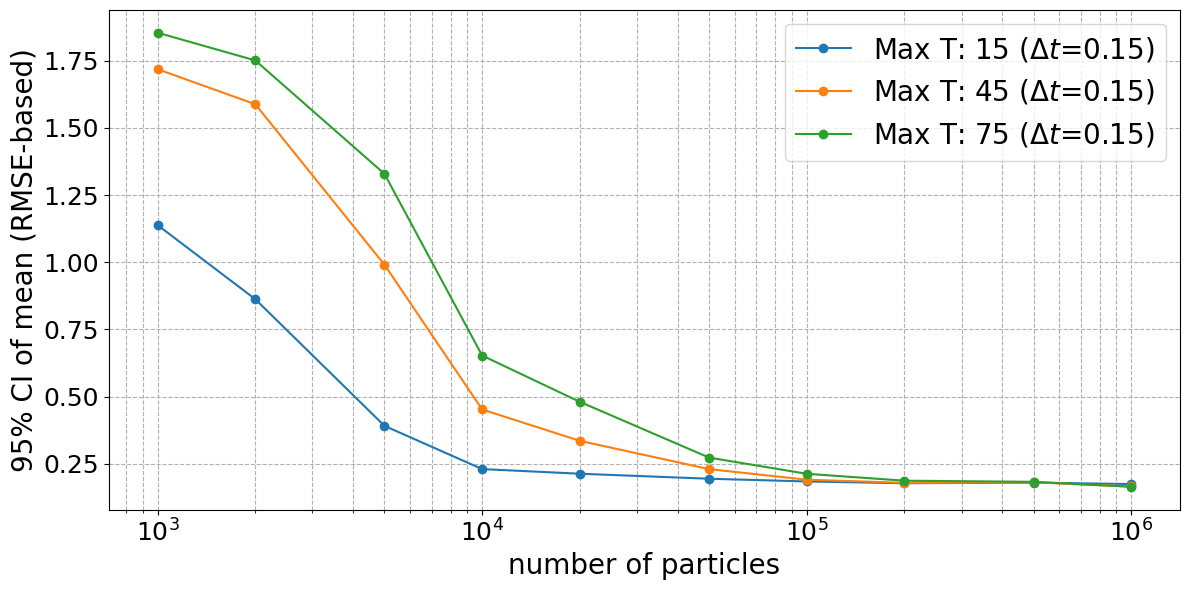

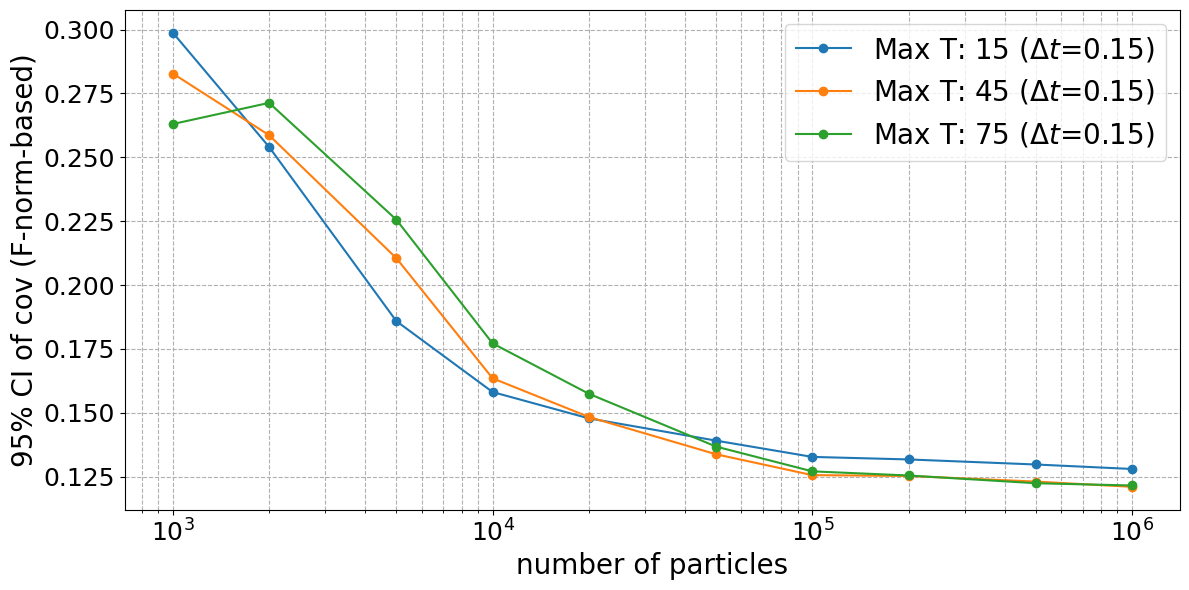


--- Plotting Complete ---


In [14]:
import torch
import os
import matplotlib.pyplot as plt
import math

# --- Configuration ---
pf_N_list = [1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000, 500000, 1000000]
seed_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 42]
max_t_list = [100, 300, 500]
data_dir = "data/lorenz63/"

# --- Part 1: Average data across seeds and save new files ---
print("--- Starting Data Averaging Process ---")
os.makedirs(data_dir, exist_ok=True)

for pf_N in pf_N_list:
    mean_tensors = []
    cov_tensors = []

    for seed in seed_list:
        file_path = f"{data_dir}pf_results_sigma_y_1.0_batch_64_len_500_pfN_{pf_N}_{seed}.pt"
        
        if os.path.exists(file_path):
            try:
                data = torch.load(file_path, weights_only=True)
                mean_tensors.append(data[0]['means'])
                cov_tensors.append(data[0]['covs'])
            except Exception as e:
                print(f"Could not load or process file {file_path}: {e}")
        else:
            print(f"Warning: File not found and will be skipped: {file_path}")

    if not mean_tensors:
        print(f"No data found for pf_N = {pf_N}, skipping.")
        continue

    avg_mean = torch.mean(torch.stack(mean_tensors), dim=0)
    avg_cov = torch.mean(torch.stack(cov_tensors), dim=0)

    output_data = [{'means': avg_mean, 'covs': avg_cov}]
    
    output_path = f"{data_dir}pf_results_sigma_y_1.0_batch_64_len_500_pfN_{pf_N}_avg.pt"
    torch.save(output_data, output_path)
    
    print(f"Successfully created: {output_path}")

print("\n--- Data Averaging Complete ---\n")


# --- Part 2: Calculate 95% CI and Plot Results ---
print("--- Starting Plotting Process ---")

fig1 = plt.figure(figsize=(12, 6))
fig2 = plt.figure(figsize=(12, 6))
ax1 = fig1.add_subplot(1, 1, 1)
ax2 = fig2.add_subplot(1, 1, 1)
ax1.set_xscale('log')
ax2.set_xscale('log')

num_seeds = len(seed_list)

for max_t in max_t_list:
    ci_95_mean_list = []
    ci_95_cov_list = []
    for pf_N in pf_N_list:
        mean_list = []
        cov_list =[]
        for seed in seed_list:
            data_name = f"{data_dir}pf_results_sigma_y_1.0_batch_64_len_500_pfN_{pf_N}_{seed}.pt"
            data = torch.load(data_name, weights_only=True)
            mean_list.append(data[0]['means'])
            cov_list.append(data[0]['covs'])
            
        mean_tensor = torch.stack(mean_list)[:, :max_t, :, :]
        cov_tensor = torch.stack(cov_list)[:, :max_t, :, :]
        
        avg_mean_across_seeds = torch.mean(mean_tensor, dim=0, keepdim=True)
        error_mean = mean_tensor - avg_mean_across_seeds
        rmse_tensor = torch.sqrt(torch.mean(error_mean**2, dim=-1))
        se_of_rmse = torch.std(rmse_tensor, dim=0) / math.sqrt(num_seeds)
        ci_95_mean_list.append(1.96 * se_of_rmse.mean().item())

        avg_cov_across_seeds = torch.mean(cov_tensor, dim=0, keepdim=True)
        error_cov = cov_tensor - avg_cov_across_seeds
        fnorm_tensor = torch.linalg.norm(error_cov, ord='fro', dim=(-2, -1))
        se_of_fnorm = torch.std(fnorm_tensor, dim=0) / math.sqrt(num_seeds)
        ci_95_cov_list.append(1.96 * se_of_fnorm.mean().item())

        max_T = int(max_t * 0.15)
        if pf_N == 1000000:
            print(f"Results for max_t={max_T}, pf_N={pf_N}:")
            print(f"  95% CI of Mean (RMSE-based): {ci_95_mean_list[-1]}")
            print(f"  95% CI of Cov (F-norm-based): {ci_95_cov_list[-1]}")
            
    ax1.plot(pf_N_list, ci_95_mean_list, marker='o', linestyle='-', label=fr"Max T: {max_T} ($\Delta t$=0.15)")
    ax2.plot(pf_N_list, ci_95_cov_list, marker='o', linestyle='-', label=fr"Max T: {max_T} ($\Delta t$=0.15)")

ax1.set_xlabel("number of particles", fontsize=20)
ax1.set_ylabel("95% CI of mean (RMSE-based)", fontsize=20)
ax1.legend(fontsize=20)
ax1.tick_params(axis='both', which='major', labelsize=18)
ax1.grid(True, which="both", ls="--")

ax2.set_xlabel("number of particles", fontsize=20)
ax2.set_ylabel("95% CI of cov (F-norm-based)", fontsize=20)
ax2.legend(fontsize=20)
ax2.tick_params(axis='both', which='major', labelsize=18)
ax2.grid(True, which="both", ls="--")

fig1.tight_layout()
fig2.tight_layout()

plt.show()

print("\n--- Plotting Complete ---")